In [1]:
import cv2

import matplotlib.pyplot as plt

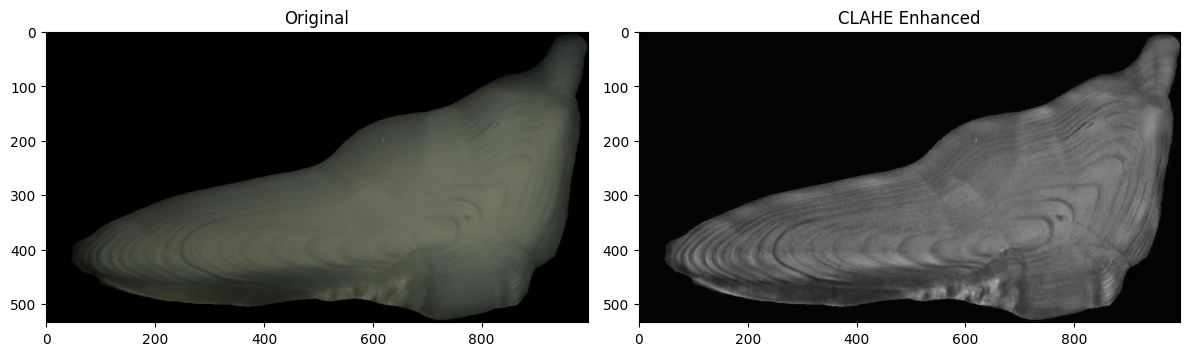

In [39]:
# Images
from numpy import tile
from skimage.filters import frangi

from src.features.extractor import clahe_enhancement



img1 = "../../../otolith_images/segmented_images/6/23625455.jpg"
img2 = "../../../otolith_images/segmented_images/6/23707006.jpg"
img3 = "../../../otolith_images/segmented_images/5/23253287.jpg"
img4 = "../../../otolith_images/segmented_images/5/23253297.jpg"
img5 = "../../../otolith_images/segmented_images/17/23993978.jpg"
img6 = "../../../otolith_images/segmented_images/1/24019892.jpg"
img7 = "../../../otolith_images/segmented_images/2/24003588.jpg"
img8 = "../../../otolith_images/segmented_images/1/24038789.jpg"
img9 = "../../../otolith_images/segmented_images/2/24163857.jpg"

# Load image
image = Image.open(img5)

enhanced = clahe_enhancement(image, repeat_clahe=False)


# inverted = 255 - enhanced
# enhanced = frangi(inverted / 255.0, sigmas=range(1, 10, 2))


# enhanced = cv2.GaussianBlur(enhanced, (0, 0), 0.5)

# enhanced = cv2.addWeighted(enhanced, 1.2, enhanced, -0.2, 0)

# Compare side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('CLAHE Enhanced')
plt.tight_layout()
plt.savefig("clahe_comparison.jpg")
plt.show()

In [19]:
import numpy as np
from PIL import Image
def clahe_enhancement(image, 
                      clip_limit: float = 3.0,
                      tile_size: int = 25, 
                      repeat_clahe: bool = True):
    """Apply CLAHE to a single image with adaptive tile grid size based on image dimensions."""
    # Convert to grayscale treating it as a Light channel
    gray_image = np.array(image.convert("L")) 
    # Extrapolate grid size from image dimensions and tile size
    h, w = gray_image.shape[:2]
    grid_y = max(1, h // tile_size)
    grid_x = max(1, w // tile_size)
    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(grid_x, grid_y))
    enhanced_image = clahe.apply(gray_image)
    if repeat_clahe:
        enhanced_image = clahe.apply(enhanced_image)
    return Image.fromarray(np.stack([enhanced_image] * 3, axis=-1)) # Replicate to 3 channels

ImportError: cannot import name 'apply_clahe' from 'src.features' (/Users/joaodsm/Desktop/Joao Workspace/PhD Compilation/otolith-cod/src/features/__init__.py)

# Clahe Stacking

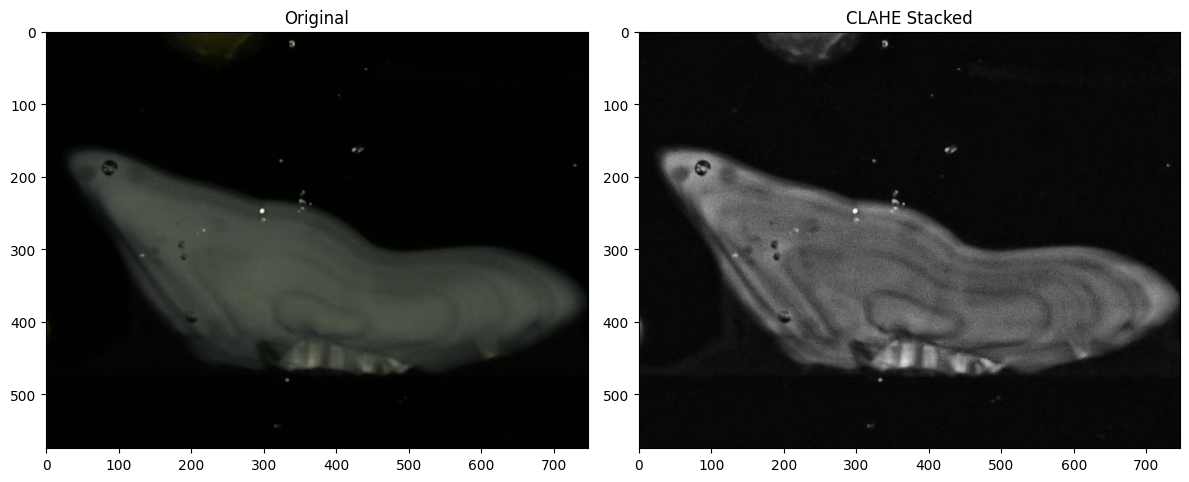

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img4 = "/Users/joaodsm/Library/CloudStorage/OneDrive-PublicAdministration/PhD-data/otolith_data/otolith_images/5/23253297.jpg"

# Load image
image = Image.open(img4)

enhanced = clahe_enhancement(image, repeat_clahe=False)

# enhanced = enhanced.astype(np.uint8)

# Compare side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('CLAHE Stacked')
plt.tight_layout()
#plt.savefig("clahe_comparison.jpg")
plt.show()

# Peak at Features

['features', 'labels', 'measurement_ids']
Features shape: (8637, 1152)
Labels unique: [ 1  2  3  4  5  6  7  8  9 10]
CLAHE Features shape: (8637, 1152)
CLAHE Labels unique: [ 1  2  3  4  5  6  7  8  9 10]
Intra-class cosine sim: 0.916 ± 0.028
Inter-class cosine sim: 0.911 ± 0.033
CLAHE Intra-class cosine sim: 0.907 ± 0.034
CLAHE Inter-class cosine sim: 0.900 ± 0.039


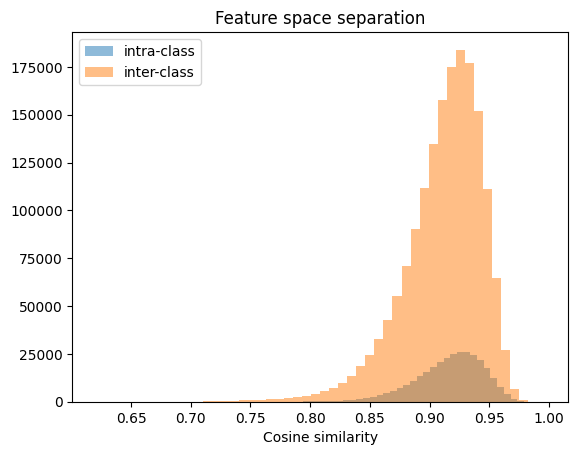

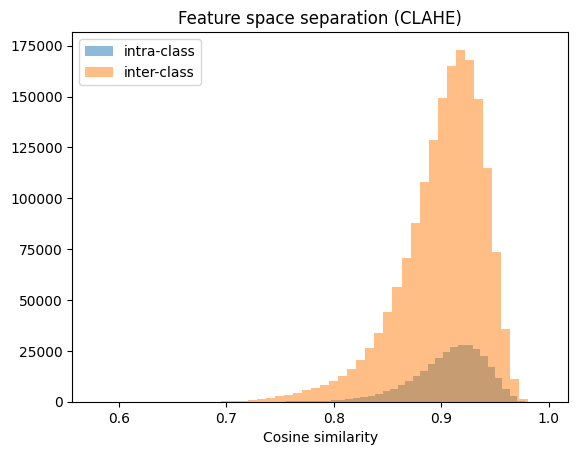

In [68]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

data = np.load("../../../outputs/embeddings/siglip2-so400m-14-384_embeddings.npz")
data_clahe = np.load("../../../outputs/embeddings/siglip2-so400m-14-384_clahe_embeddings.npz")
print(data.files)  # see what's inside

features = data["features"]
labels = data["labels"]

print("Features shape:", features.shape)
print("Labels unique:", np.unique(labels))

features_clahe = data_clahe["features"]
labels_clahe = data_clahe["labels"]

print("CLAHE Features shape:", features_clahe.shape)
print("CLAHE Labels unique:", np.unique(labels_clahe))

# Intra vs inter class distances
sample_idx = np.random.choice(len(features), 2000, replace=False)
X = features[sample_idx]
y = labels[sample_idx]
## Clahe
X_clahe = features_clahe[sample_idx]
y_clahe = labels_clahe[sample_idx]

# Similarity matrices
sim_matrix = cosine_similarity(X)
sim_matrix_clahe = cosine_similarity(X_clahe)

# Separate intra-class and inter-class similarities
intra, inter = [], []
intra_clahe, inter_clahe = [], []
for i in range(len(X)):
    for j in range(i+1, len(X)):
        if y[i] == y[j]:
            intra.append(sim_matrix[i,j])
        else:
            inter.append(sim_matrix[i,j])

for i in range(len(X_clahe)):
    for j in range(i+1, len(X_clahe)):
        if y_clahe[i] == y_clahe[j]:
            intra_clahe.append(sim_matrix_clahe[i,j])
        else:
            inter_clahe.append(sim_matrix_clahe[i,j])

print(f"Intra-class cosine sim: {np.mean(intra):.3f} ± {np.std(intra):.3f}")
print(f"Inter-class cosine sim: {np.mean(inter):.3f} ± {np.std(inter):.3f}")

print(f"CLAHE Intra-class cosine sim: {np.mean(intra_clahe):.3f} ± {np.std(intra_clahe):.3f}")
print(f"CLAHE Inter-class cosine sim: {np.mean(inter_clahe):.3f} ± {np.std(inter_clahe):.3f}")  


# Plot
plt.hist(intra, bins=50, alpha=0.5, label="intra-class")
plt.hist(inter, bins=50, alpha=0.5, label="inter-class")
plt.xlabel("Cosine similarity")
plt.legend()
plt.title("Feature space separation")
plt.show()

# Plot CLAHE
plt.hist(intra_clahe, bins=50, alpha=0.5, label="intra-class")
plt.hist(inter_clahe, bins=50, alpha=0.5, label="inter-class")
plt.xlabel("Cosine similarity")
plt.legend()
plt.title("Feature space separation (CLAHE)")
plt.show()



In [69]:
print("Features identical:", np.allclose(features, features_clahe))
print("Mean absolute difference:", np.abs(features - features_clahe).mean())
print("Max absolute difference:", np.abs(features - features_clahe).max())

diff = features_clahe - features
feature_norm = np.linalg.norm(features, axis=1).mean()
diff_norm = np.linalg.norm(diff, axis=1).mean()

print(f"Mean feature norm: {feature_norm:.4f}")
print(f"Mean diff norm: {diff_norm:.4f}")
print(f"Relative change: {diff_norm / feature_norm:.4f} ({100 * diff_norm / feature_norm:.2f}%)")

# Also cosine similarity between original and clahe per image
from sklearn.metrics.pairwise import cosine_similarity
per_image_sim = (features * features_clahe).sum(axis=1)  # dot product of L2-normalized = cosine sim
print(f"Mean per-image cosine sim (original vs clahe): {per_image_sim.mean():.4f} ± {per_image_sim.std():.4f}")



Features identical: False
Mean absolute difference: 0.008090085
Max absolute difference: 0.10251652
Mean feature norm: 1.0000
Mean diff norm: 0.3573
Relative change: 0.3573 (35.73%)
Mean per-image cosine sim (original vs clahe): 0.9350 ± 0.0178


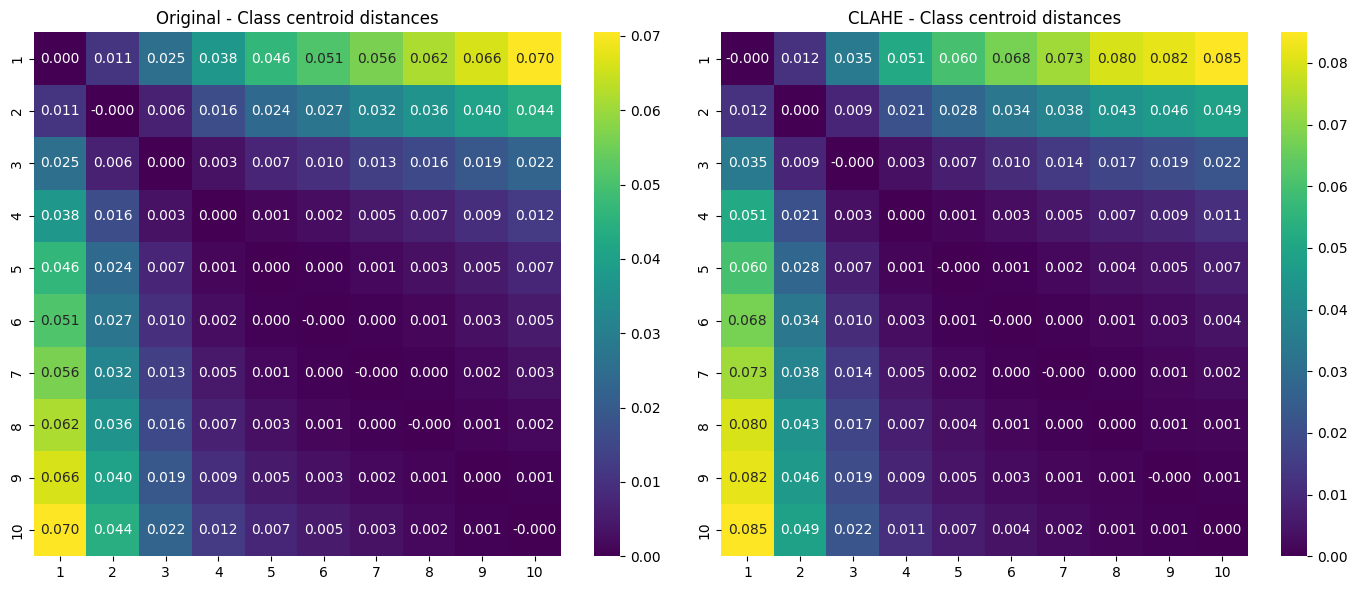

In [70]:
import pandas as pd
import seaborn as sns

unique_labels = np.unique(labels)

# Compute centroids
centroids = np.array([features[labels == l].mean(axis=0) for l in unique_labels])
centroids_clahe = np.array([features_clahe[labels_clahe == l].mean(axis=0) for l in unique_labels])

# Normalize centroids
centroids = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
centroids_clahe = centroids_clahe / np.linalg.norm(centroids_clahe, axis=1, keepdims=True)

# Cosine similarity between centroids
sim = cosine_similarity(centroids)
sim_clahe = cosine_similarity(centroids_clahe)

# Plot distance matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use distance (1 - similarity) and let colormap autoscale
sns.heatmap(1 - sim, ax=axes[0], xticklabels=unique_labels, yticklabels=unique_labels,
            cmap="viridis", annot=True, fmt=".3f")
axes[0].set_title("Original - Class centroid distances")

sns.heatmap(1 - sim_clahe, ax=axes[1], xticklabels=unique_labels, yticklabels=unique_labels,
            cmap="viridis", annot=True, fmt=".3f")
axes[1].set_title("CLAHE - Class centroid distances")

plt.tight_layout()
plt.show()



Class 1: n=110, intra spread=0.3665 ± 0.0582
Class 2: n=223, intra spread=0.3250 ± 0.0583
Class 3: n=348, intra spread=0.3075 ± 0.0522
Class 4: n=768, intra spread=0.3037 ± 0.0523
Class 5: n=1695, intra spread=0.2906 ± 0.0497
Class 6: n=1941, intra spread=0.2822 ± 0.0510
Class 7: n=1477, intra spread=0.2757 ± 0.0532
Class 8: n=927, intra spread=0.2704 ± 0.0519
Class 9: n=736, intra spread=0.2572 ± 0.0494
Class 10: n=412, intra spread=0.2567 ± 0.0553


/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


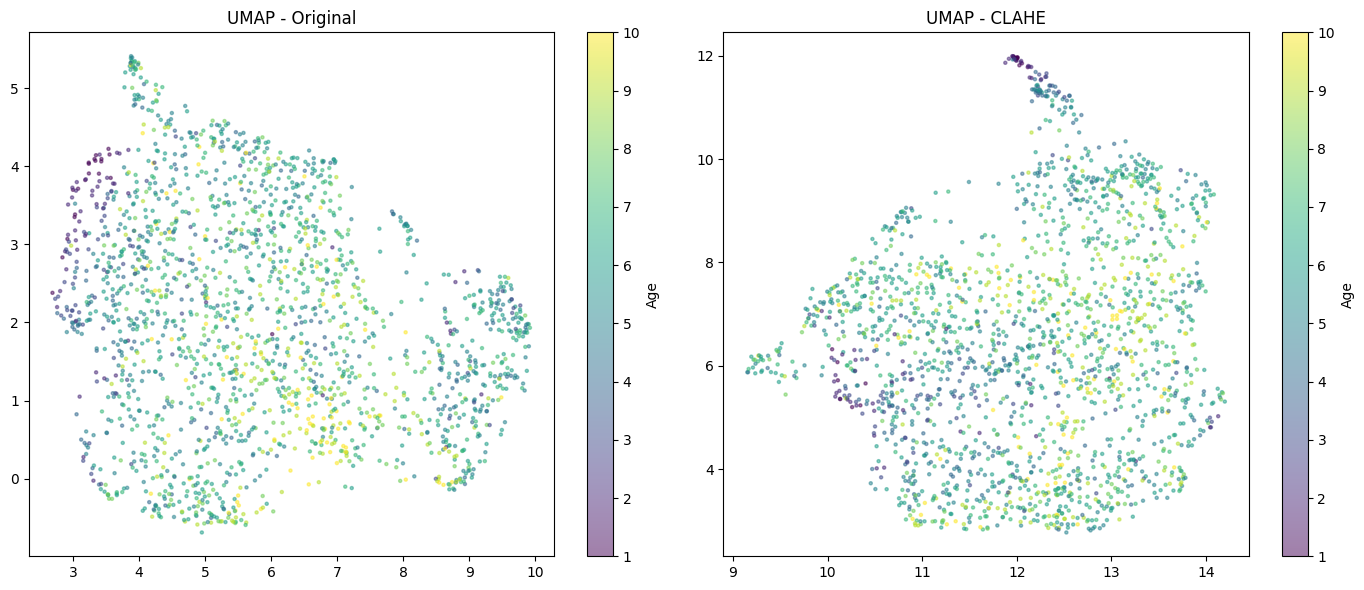

In [71]:
for l in unique_labels:
    class_features = features[labels == l]
    centroid = class_features.mean(axis=0)
    dists = np.linalg.norm(class_features - centroid, axis=1)
    print(f"Class {l}: n={len(class_features)}, intra spread={dists.mean():.4f} ± {dists.std():.4f}")

import umap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original
reducer = umap.UMAP(n_components=2, n_neighbors=30, random_state=42)
X_2d = reducer.fit_transform(features[sample_idx])
sc = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="viridis", s=5, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label="Age")
axes[0].set_title("UMAP - Original")

# CLAHE
reducer_clahe = umap.UMAP(n_components=2, n_neighbors=30, random_state=42)
X_2d_clahe = reducer_clahe.fit_transform(features_clahe[sample_idx])
sc2 = axes[1].scatter(X_2d_clahe[:, 0], X_2d_clahe[:, 1], c=y_clahe, cmap="viridis", s=5, alpha=0.5)
plt.colorbar(sc2, ax=axes[1], label="Age")
axes[1].set_title("UMAP - CLAHE")

plt.tight_layout()
plt.show()

In [53]:
# Fit CLAHE UMAP and get coordinates
reducer_clahe = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_2d_clahe = reducer_clahe.fit_transform(features_clahe[sample_idx])

# Define bounding box for top-left cluster (adjust based on plot)
mask_cluster = (X_2d_clahe[:, 0] < 8.1) & (X_2d_clahe[:, 1] > 6)

cluster_idx = sample_idx[mask_cluster]
cluster_labels = labels_clahe[cluster_idx]
cluster_ids = data_clahe["measurement_ids"][cluster_idx]

print(f"Points in cluster: {mask_cluster.sum()}")
print(f"Age distribution: {np.unique(cluster_labels, return_counts=True)}")
print(f"Measurement IDs: {cluster_ids}")

/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Points in cluster: 135
Age distribution: (array([1, 2, 3, 4, 5, 6, 7, 8]), array([22, 17, 14, 19, 38, 16,  8,  1]))
Measurement IDs: [24431311 24552958 23900592 24637775 24038408 24920242 24432362 24039091
 24884377 24916467 24913083 24039909 23939354 24708320 24528389 24706913
 24130295 24122968 24735660 24616309 24231415 24644335 24710324 24432104
 24122398 24427935 24428046 24379759 24616310 24716761 24894669 24768867
 24566537 24635965 24552955 23939846 24122273 24133901 24644217 24496087
 23939352 24432516 24374590 24528647 24528383 24428363 24432095 24552019
 24122401 23252819 24500136 24613594 24496793 24427932 24431004 24526099
 24431011 24920548 24419883 24039585 24130253 24565276 24428042 24500138
 24864969 24714886 24616301 24613714 24420279 24708692 24428134 24780768
 24751539 24431184 24528644 24884380 24134289 23900605 24427999 24920550
 24431313 24120453 24377757 23939355 24565274 24500324 24495927 24427931
 24526100 24644204 24884374 24254129 24499035 24616766 24565566 

In [66]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path
import importlib
from src.features import extractor
importlib.reload(extractor)
from src.features.extractor import clahe_enhancement  # import AFTER reload


out_dir = "/tmp/cluster_images"
os.makedirs(out_dir, exist_ok=True)

for i, (mid, label) in enumerate(zip(cluster_ids, labels_clahe[sample_idx[mask_cluster]])):
    for ext in [".jpg", ".jpeg", ".png", ".JPG"]:
        full_path = f"../../../otolith_images/{label}/{mid}{ext}"
        if os.path.exists(full_path):
            img = clahe_enhancement(Image.open(full_path))
            img.save(f"{out_dir}/{i:03d}_age{label}_id{mid}.png")
            break

os.system(f"open {out_dir}")

0